# U-DIADS-TL stage-2 loss ablation — 1024 × 256

This is the U-DIADS-TL counterpart of `train_crops_loss_ablation.ipynb`. It trains three `smp.Unet` models with an ImageNet-pretrained ResNet-34 encoder for 50 epochs. Every setting is fixed across arms except the post-warm-up loss.

| arm | epochs 1–10 | epochs 11–50 |
|---|---|---|
| `bce` | BCEWithLogitsLoss | BCEWithLogitsLoss |
| `tversky` | BCEWithLogitsLoss | Tversky (alpha=0.3, beta=0.7) |
| `supervoxel` | BCEWithLogitsLoss | SuperVoxelLoss2D (alpha=0.5, beta=0.5) |

U-DIADS has binary line-band GT rather than PAGE polygons. Each connected GT component is one text-line instance, so each crop target contains only its selected component. The native detector crop is resized to **1024 × 256 before prediction**, and evaluation resizes probabilities back to the native detector-box size before thresholding/stitching.

In [1]:
from pathlib import Path
import subprocess, sys

SUBSET = 'Latin14396'
CROP_W, CROP_H = 1024, 256
EPOCHS, WARMUP_EPOCHS = 50, 10
SEED = 1337

HERE = Path.cwd()
if not (HERE / 'train_crops_loss_ablation_2stage.py').exists():
    HERE = HERE / '50_modelling' / '02_2stage'
REPO = HERE.parents[1]
RUNNER = HERE / 'train_crops_loss_ablation_2stage.py'
OUT = REPO / '80_models/02_2stage/u-diads-tl/crop_seg_loss_ablation_components_1024x256' / SUBSET
assert RUNNER.exists(), RUNNER
print('runner:', RUNNER)
print('outputs:', OUT)

runner: /home/artur/Thesis/fsl-tl-manuscripts/50_modelling/02_2stage/train_crops_loss_ablation_2stage.py
outputs: /home/artur/Thesis/fsl-tl-manuscripts/80_models/02_2stage/u-diads-tl/crop_seg_loss_ablation_components_1024x256/Latin14396


## Train all three arms

The runner resets Python, NumPy, PyTorch, DataLoader, and Albumentations seeds before every arm. It uses the provided train/validation split, identical augmentations, AdamW (`lr=3e-4`, `weight_decay=1e-4`), and writes each epoch to `history.csv`. Completed arms are detected and skipped safely on a repeated run. The Python 3.11+ `random.sample(set, 1)` incompatibility in upstream `supervoxel-loss` is patched locally without changing its sampling distribution.

In [2]:
command = [
    sys.executable, str(RUNNER),
    '--subset', SUBSET,
    '--crop-width', str(CROP_W), '--crop-height', str(CROP_H),
    '--epochs', str(EPOCHS), '--warmup-epochs', str(WARMUP_EPOCHS),
    '--seed', str(SEED),
]
subprocess.run(command, check=True)

device=cuda subset=Latin14396 resize=1024x256 train_components=232 val_components=785 output=/home/artur/Thesis/fsl-tl-manuscripts/80_models/02_2stage/u-diads-tl/crop_seg_loss_ablation_components_1024x256/Latin14396
[bce] already complete; loaded saved history
[tversky] already complete; loaded saved history
[supervoxel] already complete; loaded saved history

       arm  best_epoch  iou@bestDice  dice@bestDice  precision@bestDice  recall@bestDice
       bce          49      0.901369       0.948126            0.940653         0.955718
   tversky          26      0.890599       0.942134            0.924883         0.960042
supervoxel          24      0.896162       0.945238            0.943943         0.946536


DONE -> /home/artur/Thesis/fsl-tl-manuscripts/80_models/02_2stage/u-diads-tl/crop_seg_loss_ablation_components_1024x256/Latin14396


CompletedProcess(args=['/home/artur/Thesis/fsl-tl-manuscripts/.venv/bin/python3', '/home/artur/Thesis/fsl-tl-manuscripts/50_modelling/02_2stage/train_crops_loss_ablation_2stage.py', '--subset', 'Latin14396', '--crop-width', '1024', '--crop-height', '256', '--epochs', '50', '--warmup-epochs', '10', '--seed', '1337'], returncode=0)

## Crop-validation summary and fixed qualitative comparison

,arm,best_epoch,iou@bestDice,dice@bestDice,precision@bestDice,recall@bestDice
0,bce,49,0.9014,0.9481,0.9407,0.9557
1,tversky,26,0.8906,0.9421,0.9249,0.9600
2,supervoxel,24,0.8962,0.9452,0.9439,0.9465


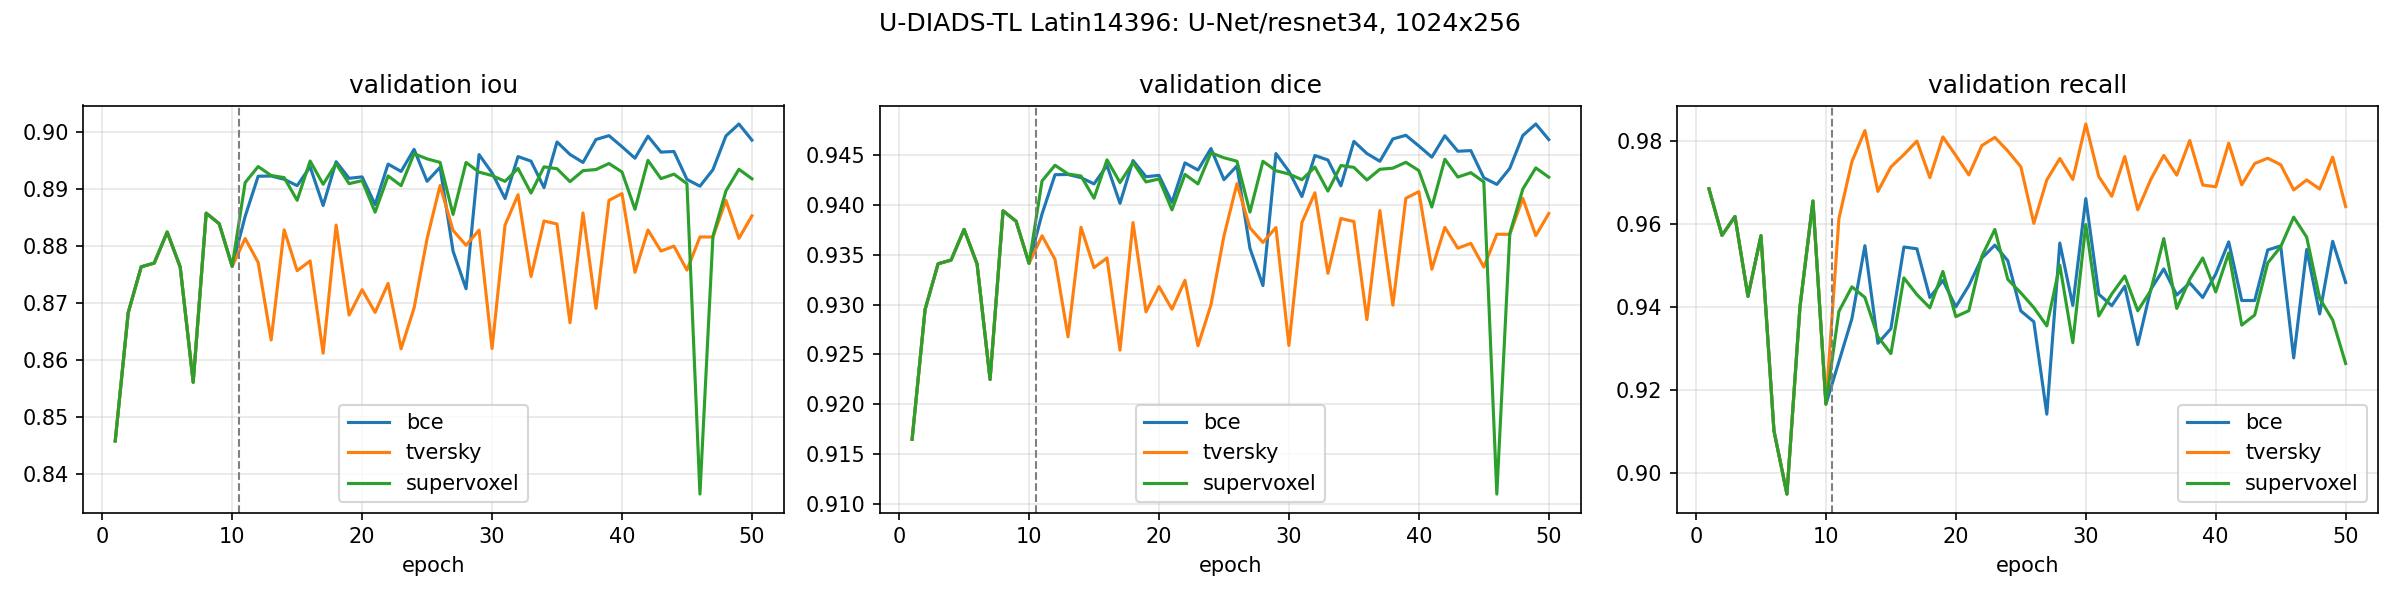

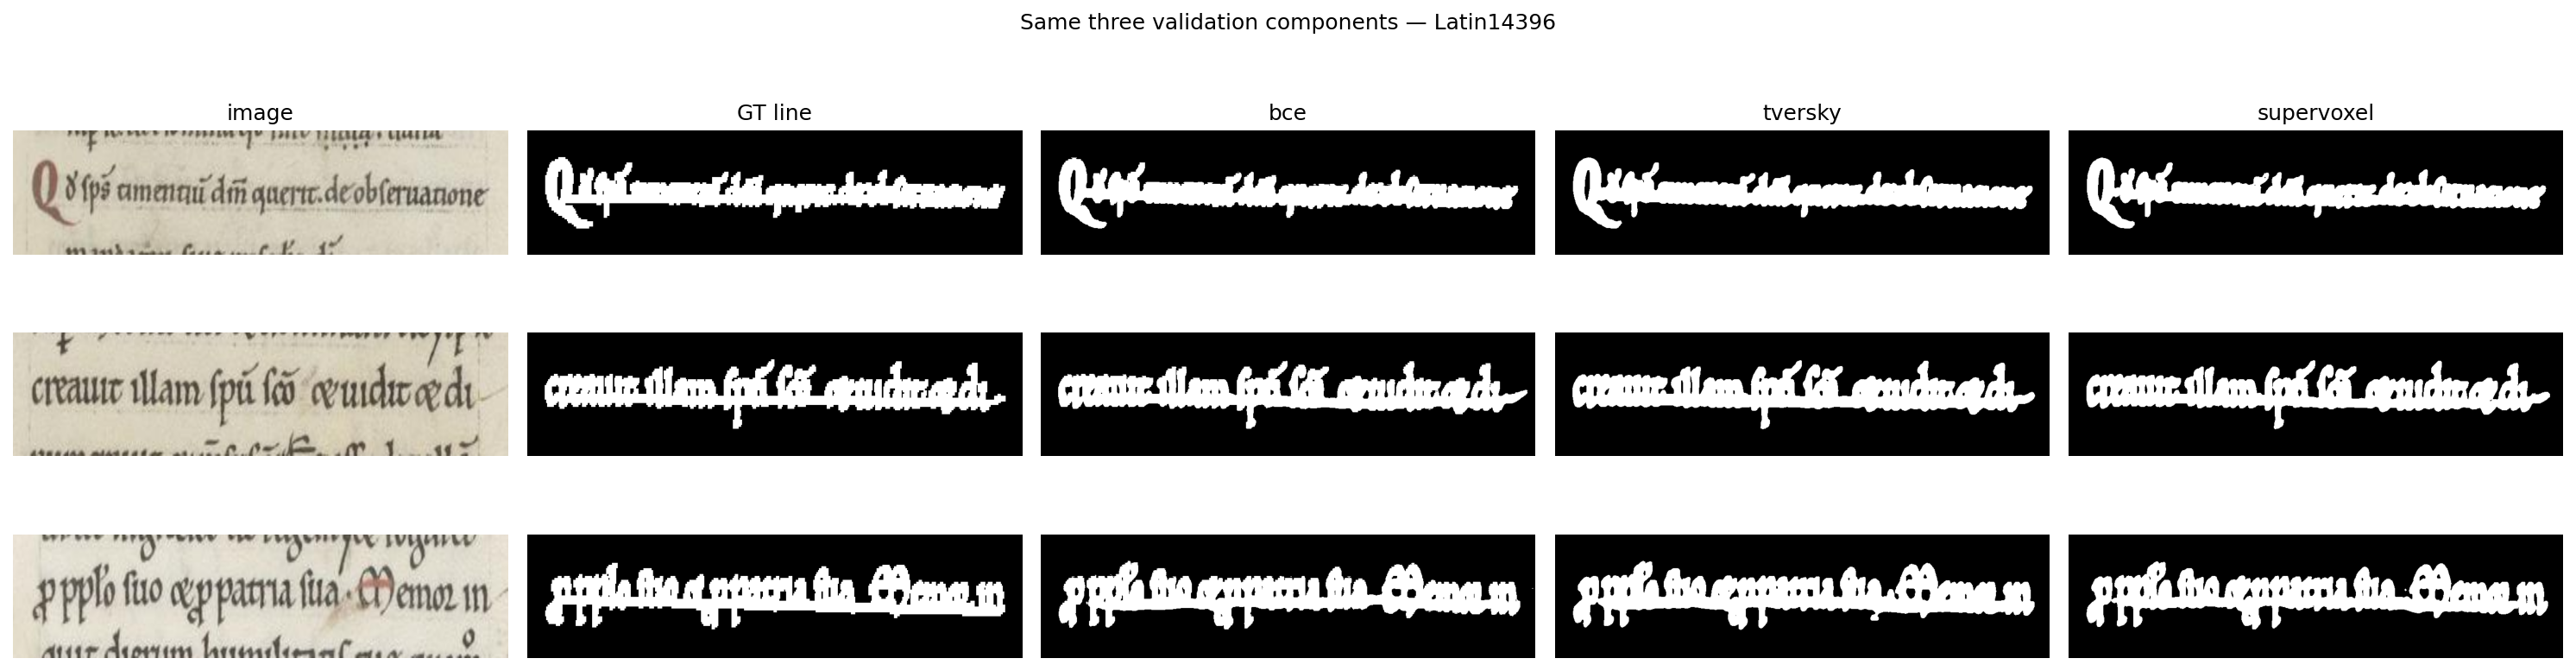

In [3]:
import pandas as pd
from IPython.display import display, Image

display(pd.read_csv(OUT / 'summary.csv').round(4))
display(Image(filename=str(OUT / 'curves.png')))
display(Image(filename=str(OUT / 'qualitative_3crops.png')))

## End-to-end evaluation

The companion evaluator holds each RF-DETR/RT-DETR detector's test boxes fixed across all three segmenters, restores every crop probability map from 1024 × 256 to its original padded box size, stitches one integer instance per detection, and reports the official U-DIADS/Zottin metrics: Pixel_IU, Line_IU, DR, RA, and FM. Detector confidence is selected on validation only.

In [4]:
DETECTOR_RUNNER = HERE / 'train_hf_detr_udiads.py'
EVALUATOR = HERE / 'evaluate_loss_ablation_detr_udiads.py'
subprocess.run([sys.executable, str(DETECTOR_RUNNER), '--subset', SUBSET], check=True)
subprocess.run([sys.executable, str(EVALUATOR), '--subset', SUBSET], check=True)

subset=Latin14396 pages=train:3, val:10, test:15
[RF-DETR] already complete -> /home/artur/Thesis/fsl-tl-manuscripts/80_models/02_2stage/u-diads-tl/detection/hf_detr_latin14396_square_geometry/rf_detr/best_model
[RT-DETR] already complete -> /home/artur/Thesis/fsl-tl-manuscripts/80_models/02_2stage/u-diads-tl/detection/hf_detr_latin14396_square_geometry/rt_detr/best_model

  model              checkpoint  validation_mAP@50  validation_mAP@50-95  test_mAP@50  test_mAP@50-95                                                                                                                         best_checkpoint  train_runtime_seconds
RF-DETR Roboflow/rf-detr-medium           0.015170              0.004307     0.014483        0.004045 /home/artur/Thesis/fsl-tl-manuscripts/80_models/02_2stage/u-diads-tl/detection/hf_detr_latin14396_square_geometry/rf_detr/checkpoint-79               364.8226
RT-DETR    PekingU/rtdetr_r50vd           0.765138              0.618166     0.771854        0.622273 

detector       loss  checkpoint_epoch  n_pages  mean_boxes  Pixel_IU  Line_IU       DR       RA       FM
 rf_detr        bce                49       15  271.600000  0.537801 0.248948 0.147173 0.055580 0.080594
 rf_detr    tversky                26       15  271.600000  0.482775 0.202988 0.117047 0.036721 0.055838
 rf_detr supervoxel                24       15  271.600000  0.541122 0.245231 0.148958 0.056632 0.081929
 rt_detr        bce                49       15   81.666667  0.798595 0.932721 0.850397 0.821010 0.832211
 rt_detr    tversky                26       15   81.666667  0.795157 0.928601 0.848403 0.818760 0.830161
 rt_detr supervoxel                24       15   81.666667  0.801617 0.938049 0.855351 0.825578 0.837076
already complete -> /home/artur/Thesis/fsl-tl-manuscripts/99_evaluation/02_2stage/u-diads-tl/latin14396_loss_ablation_detr_1024x256/zottin_metrics.csv


CompletedProcess(args=['/home/artur/Thesis/fsl-tl-manuscripts/.venv/bin/python3', '/home/artur/Thesis/fsl-tl-manuscripts/50_modelling/02_2stage/evaluate_loss_ablation_detr_udiads.py', '--subset', 'Latin14396'], returncode=0)

In [5]:
DETECTOR_OUT = REPO / '80_models/02_2stage/u-diads-tl/detection' / f'hf_detr_{SUBSET.lower()}_square_geometry'
EVAL_OUT = REPO / '99_evaluation/02_2stage/u-diads-tl' / f'{SUBSET.lower()}_loss_ablation_detr_1024x256'
display(pd.read_csv(DETECTOR_OUT / f'rf_detr_vs_rt_detr_{SUBSET.lower()}_metrics.csv').round(4))
display(pd.read_csv(EVAL_OUT / 'validation_selected_thresholds.csv').round(4))
display(pd.read_csv(EVAL_OUT / 'zottin_metrics.csv').round(4))

,model,checkpoint,validation_mAP@50,validation_mAP@50-95,test_mAP@50,test_mAP@50-95,best_checkpoint,train_runtime_seconds
0,RF-DETR,Roboflow/rf-detr-medium,0.0152,0.0043,0.0145,0.0040,/home/artur/Thesis/fsl-tl-manuscripts/80_model...,364.8226
1,RT-DETR,PekingU/rtdetr_r50vd,0.7651,0.6182,0.7719,0.6223,/home/artur/Thesis/fsl-tl-manuscripts/80_model...,506.3363


,detector,confidence,box_precision@0.5,box_recall@0.5,box_F1@0.5,mean_boxes
0,rf_detr,0.21,0.0729,0.2599,0.1138,280.0
1,rt_detr,0.05,0.8747,0.8892,0.8819,79.8


,detector,loss,checkpoint_epoch,n_pages,mean_boxes,Pixel_IU,Line_IU,DR,RA,FM
0,rf_detr,bce,49,15,271.6000,0.5378,0.2489,0.1472,0.0556,0.0806
1,rf_detr,tversky,26,15,271.6000,0.4828,0.2030,0.1170,0.0367,0.0558
2,rf_detr,supervoxel,24,15,271.6000,0.5411,0.2452,0.1490,0.0566,0.0819
3,rt_detr,bce,49,15,81.6667,0.7986,0.9327,0.8504,0.8210,0.8322
4,rt_detr,tversky,26,15,81.6667,0.7952,0.9286,0.8484,0.8188,0.8302
5,rt_detr,supervoxel,24,15,81.6667,0.8016,0.9380,0.8554,0.8256,0.8371
